# RQ2 — Restructured Analysis

Unit of analysis: **org × procedure × stage**  
Outcome: **count of distinct ALIGNED provisions** per org per stage  

No alignment rates. No OPPOSING in the denominator.

Structure:
1. Load and build org-level dataset
2. Provision landscape — which provisions attracted the most correspondence
3. Within-org paired comparison — does aligned provision count change across stages?
4. Count regression — does meeting intensity predict aligned provision count?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

LABEL_COLORS = {
    'ALIGNED':      '#2ecc71',
    'OPPOSING':     '#e74c3c',
    'NOISE':        '#bdc3c7',
    'UNDETECTABLE': '#95a5a6',
}
STAGE_COLORS = {'preproposal': '#3498db', 'amendment': '#e67e22'}

PROC_LABELS = {
    '2021:0106COD': 'AI Act',
    '2020:0361COD': 'DSA',
    '2020:0374COD': 'DMA',
    '2023:0212COD': 'Digital Euro',
    '2023:0284COD': 'ELV',
    '2025:0102COD': 'CMA',
    '2022:0051COD': 'CSDDD',
    '2022:0277COD': 'EMFA',
    '2022:0396COD': 'PPWR',
}

BASE = 'analysis'

## 1. Load data

For procedures with multiple dated files, pick the most recent one (latest date in filename).  
Normalise column names across pre-proposal and amendment formats.

In [2]:
def latest_dyad_file(pdir, stage_prefix):
    """Return path to most recent *_dyads.csv for a given stage prefix."""
    candidates = [
        f for f in os.listdir(pdir)
        if f.startswith(stage_prefix) and f.endswith('_dyads.csv')
    ]
    if not candidates:
        return None
    return os.path.join(pdir, sorted(candidates)[-1])  # latest date wins


def load_dyads(path, stage, proc):
    df = pd.read_csv(path)
    df['stage'] = stage
    df['procedure'] = proc
    df['proc_label'] = PROC_LABELS.get(proc, proc)

    # Normalise provision identifier to a single column
    if 'article_number' in df.columns:
        df['provision_id'] = df['article_number'].astype(str)
    elif 'amendment_number' in df.columns:
        df['provision_id'] = df['amendment_number'].astype(str)

    # Normalise meeting column names
    if 'preproposal_meetings_total' in df.columns:
        df = df.rename(columns={
            'preproposal_meetings_total':      'meetings_total',
            'preproposal_meetings_commission': 'meetings_commission',
            'preproposal_meetings_ep':         'meetings_ep',
        })

    # Only keep HYS-sourced rows (drop commission_meeting source if present)
    if 'source_type' in df.columns:
        df = df[df['source_type'].isna() | (df['source_type'] == 'hys_feedback')]

    keep = ['organisation', 'transparency_reg_id', 'meetings_total',
            'meetings_commission', 'meetings_ep',
            'provision_id', 'similarity_score', 'label',
            'stage', 'procedure', 'proc_label']
    return df[[c for c in keep if c in df.columns]].copy()


dfs = []
for proc_dir in sorted(os.listdir(BASE)):
    pdir = os.path.join(BASE, proc_dir)
    if not os.path.isdir(pdir) or ':' not in proc_dir:
        continue
    # Skip duplicate folders with parentheses in name
    if '(' in proc_dir:
        continue
    for stage, prefix in [('preproposal', 'preproposal'), ('amendment', 'amendment')]:
        path = latest_dyad_file(pdir, prefix)
        if path:
            dfs.append(load_dyads(path, stage, proc_dir))

all_dyads = pd.concat(dfs, ignore_index=True)

# Step 2: access-based filtering — only orgs with ≥1 disclosed meeting
n_before = len(all_dyads)
all_dyads = all_dyads[all_dyads['meetings_total'] > 0]
print(f'Dropped {n_before - len(all_dyads):,} dyads from orgs with 0 meetings '
      f'({n_before - len(all_dyads)}/{n_before} = {(n_before - len(all_dyads))/n_before*100:.1f}%)')

print(f'Total dyads: {len(all_dyads):,}')
print(f'Procedures:  {all_dyads["proc_label"].nunique()}')
print()
print(all_dyads.groupby(['proc_label', 'stage'])['label'].value_counts().unstack(fill_value=0))

Dropped 1,359 dyads from orgs with 0 meetings (1359/9161 = 14.8%)
Total dyads: 7,802
Procedures:  9

label                     ALIGNED  NOISE  OPPOSING  UNDETECTABLE
proc_label   stage                                              
AI Act       amendment        159    223        70            78
             preproposal       43     56        14            29
CMA          amendment        384    198        84           121
             preproposal        7      6         0             3
CSDDD        amendment        198    175       116            79
             preproposal       17      3         1             3
DMA          amendment        496    428       120           184
             preproposal       25     26         0             9
DSA          amendment        447    554       211           253
             preproposal       74     58        16            30
Digital Euro amendment        225    200       104           170
ELV          amendment        406    282       126    

## 2. Build org-level dataset

Collapse from dyad level to **org × procedure × stage**.  
Key columns:
- `count_aligned` — distinct provisions with ALIGNED label  
- `total_provisions` — distinct provisions appearing in *any* dyad for this org/proc/stage (used as exposure)
- `meetings_total` — access measure

In [3]:
def org_level(df):
    return df.groupby(['organisation', 'procedure', 'proc_label', 'stage']).agg(
        meetings_total    = ('meetings_total', 'first'),
        meetings_comm     = ('meetings_commission', 'first'),
        meetings_ep       = ('meetings_ep', 'first'),
        count_aligned     = ('label', lambda x: (x == 'ALIGNED').sum()),
        count_opposing    = ('label', lambda x: (x == 'OPPOSING').sum()),
        count_noise       = ('label', lambda x: (x == 'NOISE').sum()),
        count_undetect    = ('label', lambda x: (x == 'UNDETECTABLE').sum()),
        total_dyads       = ('label', 'count'),
        # distinct provisions this org matched (our exposure)
        n_provisions_matched = ('provision_id', 'nunique'),
    ).reset_index()

orgs = org_level(all_dyads)

# Total distinct provisions per procedure × stage across ALL orgs
# (corpus exposure — how many provisions were searchable)
corpus_size = (
    all_dyads.groupby(['procedure', 'stage'])['provision_id']
    .nunique()
    .reset_index(name='corpus_provisions')
)
orgs = orgs.merge(corpus_size, on=['procedure', 'stage'], how='left')

# Coverage: share of corpus provisions this org aligned with
orgs['coverage'] = orgs['count_aligned'] / orgs['corpus_provisions']

print(f'Org × procedure × stage rows: {len(orgs):,}')
print(f'Unique orgs: {orgs["organisation"].nunique()}')
print()
print(orgs.groupby(['proc_label', 'stage'])[['count_aligned', 'corpus_provisions', 'meetings_total']]
      .agg(['mean', 'median', 'max']).round(1))

Org × procedure × stage rows: 326
Unique orgs: 290

                         count_aligned            corpus_provisions         \
                                  mean median max              mean median   
proc_label   stage                                                           
AI Act       amendment            14.5   13.0  36             347.0  347.0   
             preproposal           2.9    2.0  15              58.0   58.0   
CMA          amendment            19.2   18.0  74             377.0  377.0   
             preproposal           1.8    1.5   3              13.0   13.0   
CSDDD        amendment             4.6    3.0  22             237.0  237.0   
             preproposal           3.4    3.0   7              13.0   13.0   
DMA          amendment            17.7    8.5  92             588.0  588.0   
             preproposal           2.8    2.0  10              24.0   24.0   
DSA          amendment            11.5    8.0  34             616.0  616.0   
            

## 3. Provision landscape

For each procedure × stage: which provisions attracted ALIGNED correspondence  
from the most distinct organisations?  

This is the article-level view — what got lobbied, not who lobbied.

In [4]:
# Per-provision: count distinct orgs with ALIGNED label
prov_landscape = (
    all_dyads[all_dyads['label'] == 'ALIGNED']
    .groupby(['procedure', 'proc_label', 'stage', 'provision_id'])
    .agg(n_aligned_orgs=('organisation', 'nunique'))
    .reset_index()
)

# Add proc_label to corpus_size for easy joining
proc_label_map = all_dyads[['procedure', 'proc_label']].drop_duplicates()
corpus_labeled = corpus_size.merge(proc_label_map, on='procedure', how='left')

# Coverage: share of provisions in each procedure × stage with ≥1 ALIGNED org
cov = (
    prov_landscape.groupby(['proc_label', 'stage'])['provision_id'].nunique()
    .reset_index(name='provisions_with_aligned')
)
cov = cov.merge(
    corpus_labeled[['proc_label', 'stage', 'corpus_provisions']],
    on=['proc_label', 'stage'], how='left'
)
cov['pct_covered'] = (cov['provisions_with_aligned'] / cov['corpus_provisions'] * 100).round(1)

pivot_cov = cov.pivot(index='proc_label', columns='stage',
                      values=['provisions_with_aligned', 'corpus_provisions', 'pct_covered'])
print('Provision coverage by procedure × stage:')
print(pivot_cov.to_string())

Provision coverage by procedure × stage:
             provisions_with_aligned             corpus_provisions             pct_covered            
stage                      amendment preproposal         amendment preproposal   amendment preproposal
proc_label                                                                                            
AI Act                         126.0        26.0             347.0        58.0        36.3        44.8
CMA                            232.0         6.0             377.0        13.0        61.5        46.2
CSDDD                           96.0        11.0             237.0        13.0        40.5        84.6
DMA                            332.0        14.0             588.0        24.0        56.5        58.3
DSA                            276.0        40.0             616.0        63.0        44.8        63.5
Digital Euro                   171.0         NaN             389.0         NaN        44.0         NaN
ELV                            2

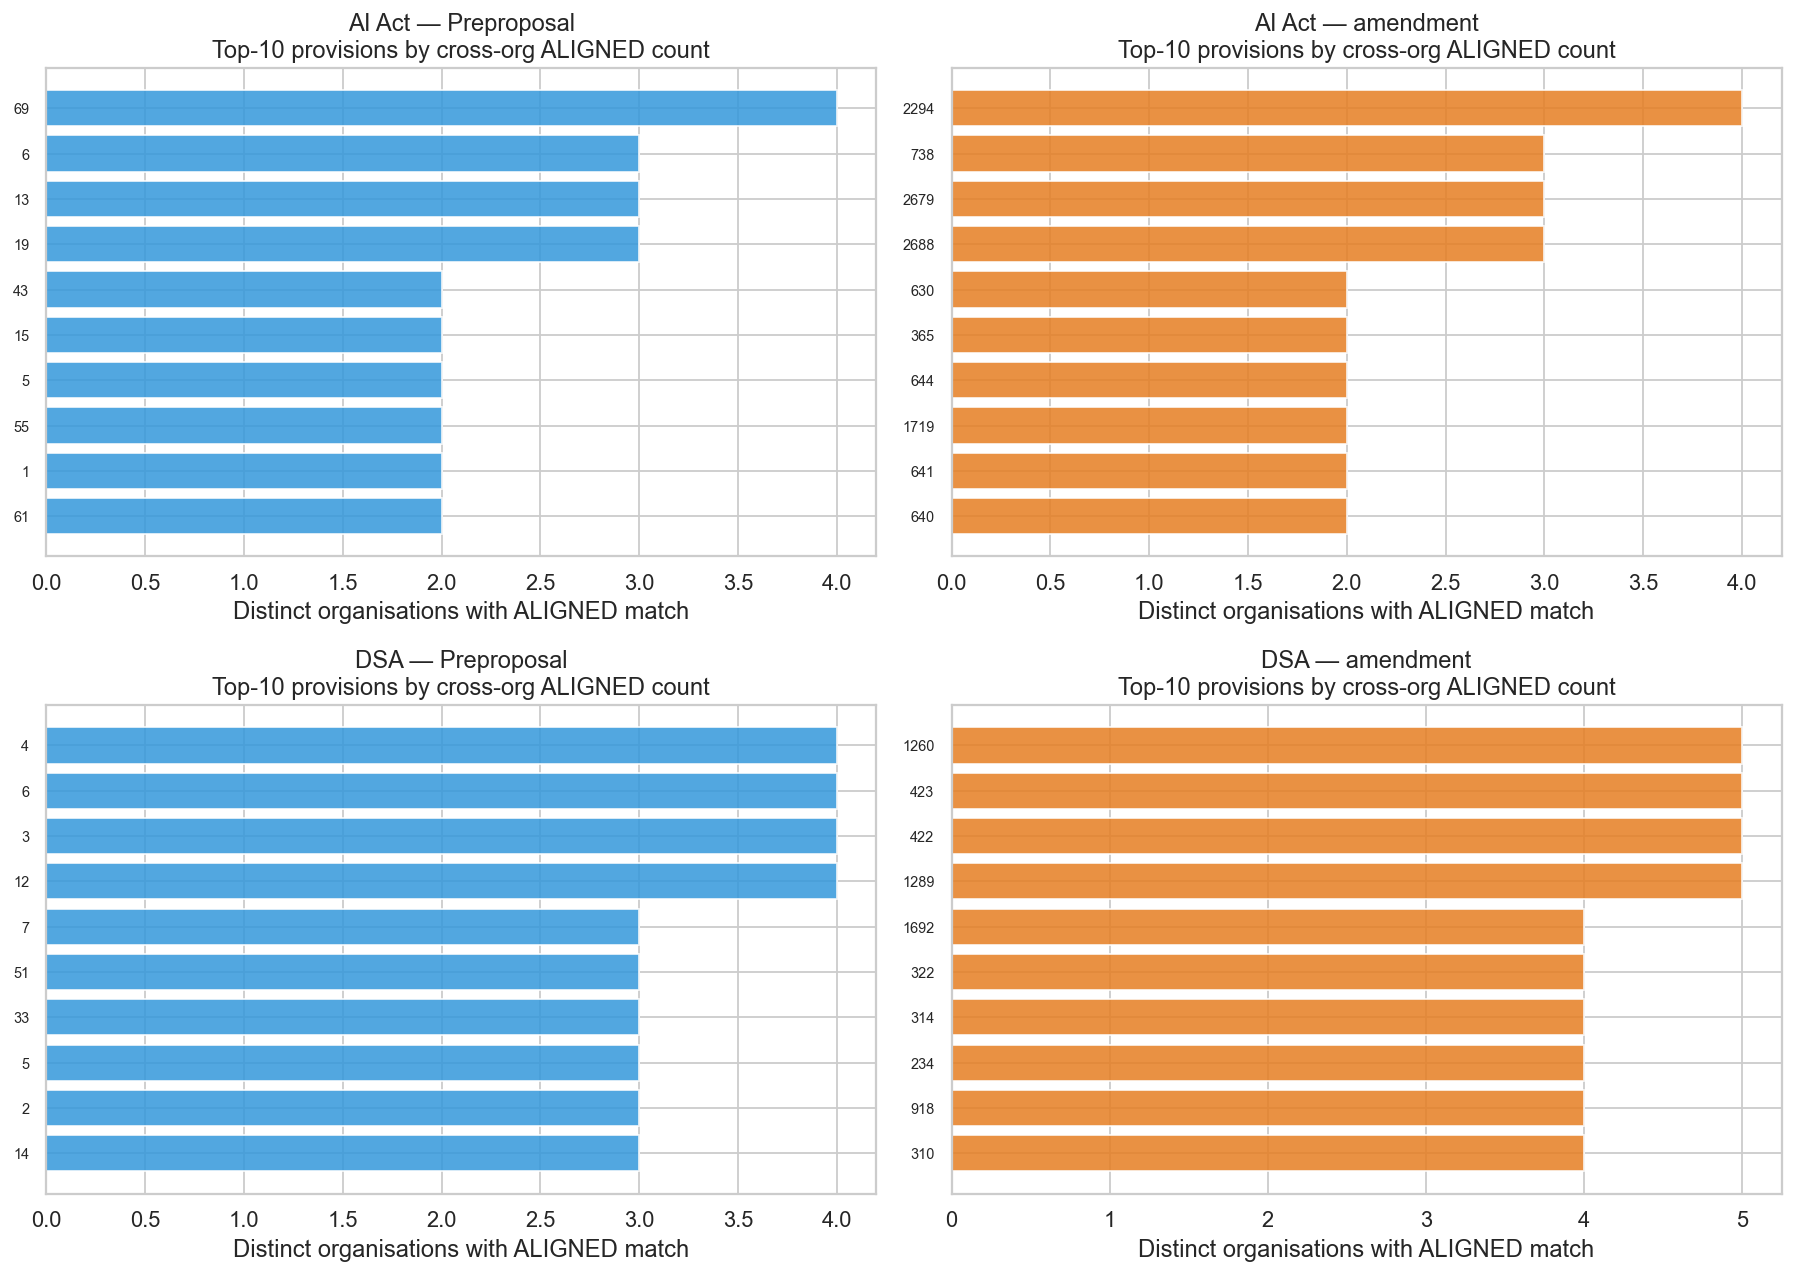

Saved fig_provision_landscape.png


In [5]:
# ── Top-10 provisions per procedure × stage ────────────────────────────────
# Show for the two largest procedures: AI Act and DSA

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_i, proc in enumerate(['AI Act', 'DSA']):
    for col_i, stage in enumerate(['preproposal', 'amendment']):
        ax = axes[row_i][col_i]
        sub = (
            prov_landscape[
                (prov_landscape['proc_label'] == proc) &
                (prov_landscape['stage'] == stage)
            ]
            .sort_values('n_aligned_orgs', ascending=True)
            .tail(10)
        )
        if len(sub) == 0:
            ax.set_title(f'{proc} — {stage} (no data)')
            continue
        ax.barh(sub['provision_id'].astype(str), sub['n_aligned_orgs'],
                color=STAGE_COLORS[stage], alpha=0.85, edgecolor='white')
        ax.set_xlabel('Distinct organisations with ALIGNED match')
        ax.set_title(f'{proc} — {stage.replace("p","P",1)}\nTop-10 provisions by cross-org ALIGNED count')
        ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('analysis/fig_provision_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_provision_landscape.png')

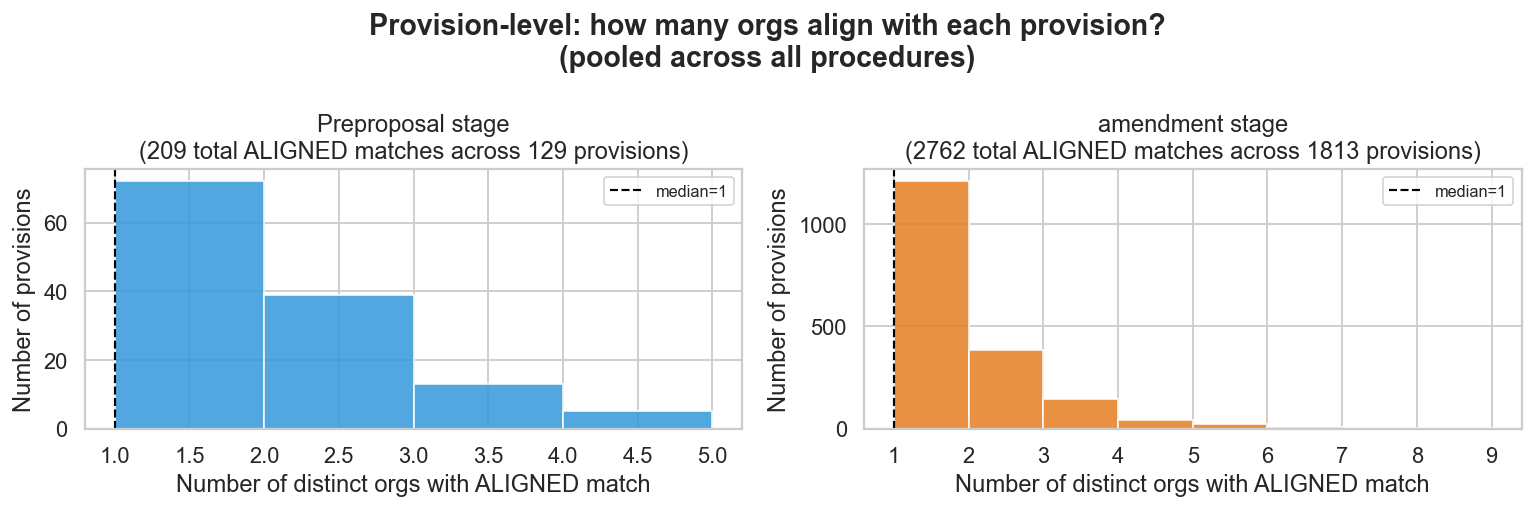

In [6]:
# ── Distribution of n_aligned_orgs per provision ──────────────────────────
# Most provisions attract 0-1 orgs; a few attract many. Show this shape.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, stage in zip(axes, ['preproposal', 'amendment']):
    data = prov_landscape[prov_landscape['stage'] == stage]['n_aligned_orgs']
    ax.hist(data, bins=range(1, data.max() + 2), color=STAGE_COLORS[stage],
            edgecolor='white', alpha=0.85)
    ax.set_xlabel('Number of distinct orgs with ALIGNED match')
    ax.set_ylabel('Number of provisions')
    ax.set_title(f'{stage.replace("p","P",1)} stage\n'
                 f'({data.sum()} total ALIGNED matches across {len(data)} provisions)')
    med = data.median()
    ax.axvline(med, color='black', ls='--', lw=1.2, label=f'median={med:.0f}')
    ax.legend(fontsize=9)

fig.suptitle('Provision-level: how many orgs align with each provision?\n'
             '(pooled across all procedures)', fontweight='bold')
plt.tight_layout()
plt.savefig('analysis/fig_provision_org_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Within-org paired comparison

Keep only orgs that appear at **both** stages of the **same** procedure.  
For each such org, compare `count_aligned` pre-proposal vs amendment.  

**Why this is better than comparing aggregate rates:**  
The org is its own control. Differences in org size, type, and engagement style cancel out.  
We're asking: does the same org correspond with more or fewer provisions after the  
Commission proposal is tabled?

**Caveat on corpus size:**  
Amendment stages have far more provisions (hundreds to thousands of amendments vs  
~100-200 proposal articles). Raw counts are not directly comparable. We therefore  
use **coverage** = count_aligned / corpus_provisions as the outcome,  
which normalises for corpus size.

In [7]:
# Build paired dataset: orgs in BOTH stages of the same procedure
pp = orgs[orgs['stage'] == 'preproposal'][[
    'organisation', 'procedure', 'proc_label',
    'meetings_total', 'count_aligned', 'corpus_provisions', 'coverage'
]].rename(columns={
    'count_aligned':    'aligned_pp',
    'corpus_provisions':'corpus_pp',
    'coverage':         'coverage_pp',
    'meetings_total':   'meetings_pp',
})

am = orgs[orgs['stage'] == 'amendment'][[
    'organisation', 'procedure', 'proc_label',
    'meetings_total', 'count_aligned', 'corpus_provisions', 'coverage'
]].rename(columns={
    'count_aligned':    'aligned_am',
    'corpus_provisions':'corpus_am',
    'coverage':         'coverage_am',
    'meetings_total':   'meetings_am',
})

paired = pp.merge(am, on=['organisation', 'procedure', 'proc_label'], how='inner')
paired['delta_count']    = paired['aligned_am']    - paired['aligned_pp']
paired['delta_coverage'] = paired['coverage_am']   - paired['coverage_pp']
# Use the higher meeting count across stages
paired['meetings'] = paired[['meetings_pp', 'meetings_am']].max(axis=1)

print(f'Paired orgs (appear at both stages): {len(paired)}')
print(f'Across {paired["proc_label"].nunique()} procedures')
print()
print(paired.groupby('proc_label')[['aligned_pp','aligned_am','coverage_pp','coverage_am']]
      .mean().round(3))

Paired orgs (appear at both stages): 13
Across 6 procedures

            aligned_pp  aligned_am  coverage_pp  coverage_am
proc_label                                                  
AI Act             2.0        0.00        0.034        0.000
CMA                1.5       27.00        0.115        0.072
CSDDD              6.5       14.00        0.500        0.059
DMA                2.0       19.25        0.083        0.033
DSA                2.0       15.00        0.032        0.024
PPWR               2.0        3.00        0.044        0.006


In [8]:
# ── Wilcoxon signed-rank test on coverage delta ────────────────────────────
# H0: median delta_coverage = 0 (no stage difference)

print('=== Pooled: coverage pre-proposal vs amendment ===')
print(f'  N paired orgs:          {len(paired)}')
print(f'  Median coverage PP:     {paired["coverage_pp"].median():.4f}')
print(f'  Median coverage AM:     {paired["coverage_am"].median():.4f}')
print(f'  Median delta (AM - PP): {paired["delta_coverage"].median():.4f}')

if len(paired) >= 10:
    stat, p = stats.wilcoxon(paired['coverage_pp'], paired['coverage_am'],
                              alternative='two-sided')
    print(f'  Wilcoxon W={stat:.1f}, p={p:.4f}')
else:
    print('  Too few pairs for Wilcoxon test')

print()
print('=== Per procedure ===')
for proc in sorted(paired['proc_label'].unique()):
    sub = paired[paired['proc_label'] == proc]
    delta = sub['delta_coverage']
    n = len(sub)
    if n >= 5:
        w, p = stats.wilcoxon(sub['coverage_pp'], sub['coverage_am'],
                               alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {proc:<14} n={n:2d}  median Δ={delta.median():+.4f}  p={p:.3f} {sig}')
    else:
        print(f'  {proc:<14} n={n:2d}  median Δ={delta.median():+.4f}  (too few for test)')

=== Pooled: coverage pre-proposal vs amendment ===
  N paired orgs:          13
  Median coverage PP:     0.0476
  Median coverage AM:     0.0130
  Median delta (AM - PP): -0.0366
  Wilcoxon W=4.0, p=0.0017

=== Per procedure ===
  AI Act         n= 1  median Δ=-0.0345  (too few for test)
  CMA            n= 2  median Δ=-0.0438  (too few for test)
  CSDDD          n= 2  median Δ=-0.4409  (too few for test)
  DMA            n= 4  median Δ=-0.0374  (too few for test)
  DSA            n= 3  median Δ=-0.0094  (too few for test)
  PPWR           n= 1  median Δ=-0.0380  (too few for test)


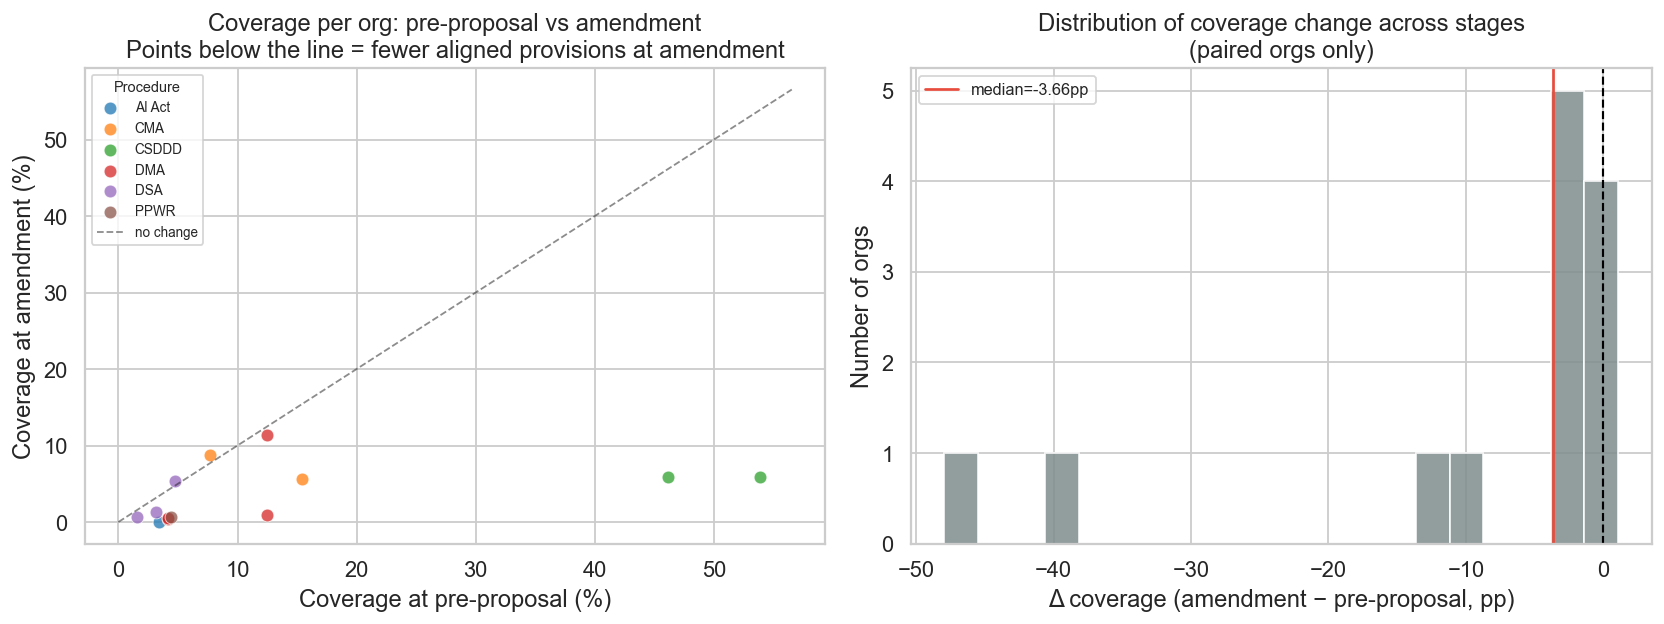

In [9]:
# ── Visualise paired comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter plot PP vs AM coverage, coloured by procedure
ax = axes[0]
palette = sns.color_palette('tab10', n_colors=paired['proc_label'].nunique())
proc_colors = dict(zip(sorted(paired['proc_label'].unique()), palette))

for proc, color in proc_colors.items():
    sub = paired[paired['proc_label'] == proc]
    ax.scatter(sub['coverage_pp'] * 100, sub['coverage_am'] * 100,
               color=color, alpha=0.75, s=50, label=proc, edgecolors='white', linewidth=0.5)

lim_max = max(paired['coverage_pp'].max(), paired['coverage_am'].max()) * 100 * 1.05
ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1, alpha=0.5, label='no change')
ax.set_xlabel('Coverage at pre-proposal (%)')
ax.set_ylabel('Coverage at amendment (%)')
ax.set_title('Coverage per org: pre-proposal vs amendment\n'
             'Points below the line = fewer aligned provisions at amendment')
ax.legend(fontsize=7.5, title='Procedure', title_fontsize=8)

# Right: delta_coverage distribution (histogram)
ax = axes[1]
ax.hist(paired['delta_coverage'] * 100, bins=20,
        color='#7f8c8d', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', ls='--', lw=1.2)
ax.axvline(paired['delta_coverage'].median() * 100, color='#e74c3c',
           ls='-', lw=1.5, label=f'median={paired["delta_coverage"].median()*100:+.2f}pp')
ax.set_xlabel('Δ coverage (amendment − pre-proposal, pp)')
ax.set_ylabel('Number of orgs')
ax.set_title('Distribution of coverage change across stages\n(paired orgs only)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('analysis/fig_paired_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Count regression

**What is a count model?**

Normal linear regression predicts a continuous outcome. Here the outcome (`count_aligned`) is  
a non-negative integer: 0, 1, 2, 3... This violates linear regression assumptions (can't be  
negative, often has many zeros, variance tends to grow with the mean).

**Negative binomial regression** is designed for count outcomes. It models  
`E[count] = exp(β₀ + β₁x₁ + ...)`, so predictions are always positive.  
Coefficients are interpreted as: a unit increase in x multiplies the expected count by `exp(β)`.

**Offset term**: because amendment stages have far more provisions than pre-proposal stages,  
we include `log(corpus_provisions)` as an offset. This turns the model into predicting  
*rate* (aligned provisions per searchable provision) rather than raw count.

**Three specifications:**  
- Model 1: meetings only  
- Model 2: meetings + stage + procedure fixed effects  
- Model 3: meetings + stage + interaction + procedure fixed effects  

In [10]:
# ── Prepare regression dataset ─────────────────────────────────────────────
reg = orgs.copy()
reg = reg[reg['corpus_provisions'] > 0].copy()

reg['log_meetings']    = np.log1p(reg['meetings_total'])
reg['is_preproposal']  = (reg['stage'] == 'preproposal').astype(int)
reg['log_corpus']      = np.log(reg['corpus_provisions'])  # offset
reg['interaction']     = reg['log_meetings'] * reg['is_preproposal']

# Sanitise proc_label for use as formula tokens (replace spaces/slashes with underscore)
reg['proc_label_clean'] = reg['proc_label'].str.replace(r'[^A-Za-z0-9]', '_', regex=True)
reg = pd.get_dummies(reg, columns=['proc_label_clean'], drop_first=True, dtype=float)

proc_dummies = [c for c in reg.columns if c.startswith('proc_label_clean_')]

print(f'Regression sample: {len(reg)} org×procedure×stage rows')
print(f'Orgs with 0 aligned provisions: {(reg["count_aligned"]==0).sum()} '
      f'({(reg["count_aligned"]==0).mean()*100:.1f}%)')
print(f'Mean count_aligned: {reg["count_aligned"].mean():.2f}')
print(f'Variance:           {reg["count_aligned"].var():.2f}  '
      f'(if >> mean → overdispersed → use NegBin)')
print(f'Procedure dummies: {proc_dummies}')

Regression sample: 326 org×procedure×stage rows
Orgs with 0 aligned provisions: 41 (12.6%)
Mean count_aligned: 9.11
Variance:           151.20  (if >> mean → overdispersed → use NegBin)
Procedure dummies: ['proc_label_clean_CMA', 'proc_label_clean_CSDDD', 'proc_label_clean_DMA', 'proc_label_clean_DSA', 'proc_label_clean_Digital_Euro', 'proc_label_clean_ELV', 'proc_label_clean_EMFA', 'proc_label_clean_PPWR']


In [11]:
# ── Fit negative binomial models ───────────────────────────────────────────
# statsmodels NegativeBinomial with exposure (offset)

def fit_negbin(formula_rhs, data, offset_col='log_corpus'):
    formula = f'count_aligned ~ {formula_rhs}'
    y = data['count_aligned'].values
    X = sm.add_constant(
        data[[c for c in data.columns
              if c in formula_rhs or any(c == p for p in proc_dummies)]]
    )
    return None  # placeholder — use smf below

# Build formulas
proc_fe = ' + '.join(proc_dummies) if proc_dummies else '0'

formula1 = 'count_aligned ~ log_meetings'
formula2 = f'count_aligned ~ log_meetings + is_preproposal + {proc_fe}'
formula3 = f'count_aligned ~ log_meetings + is_preproposal + interaction + {proc_fe}'

models = {}
for name, formula in [('Model 1 (meetings only)', formula1),
                       ('Model 2 (+ stage + proc FE)', formula2),
                       ('Model 3 (+ interaction)', formula3)]:
    m = smf.negativebinomial(formula, data=reg, exposure=reg['corpus_provisions']).fit(
        disp=False, method='nm', maxiter=500
    )
    models[name] = m
    print(f'\n=== {name} ===')
    core_params = ['Intercept', 'log_meetings', 'is_preproposal', 'interaction']
    show = m.params.index[m.params.index.isin(core_params)]
    summary = pd.DataFrame({
        'coef':    m.params[show].round(3),
        'exp(coef) = IRR': np.exp(m.params[show]).round(3),
        'p':       m.pvalues[show].round(3),
    })
    print(summary.to_string())
    print(f'  Pseudo-R²: {1 - m.llf/m.llnull:.3f}')


=== Model 1 (meetings only) ===
               coef  exp(coef) = IRR      p
Intercept    -3.691            0.025  0.000
log_meetings  0.197            1.217  0.037
  Pseudo-R²: 0.002

=== Model 2 (+ stage + proc FE) ===
                 coef  exp(coef) = IRR      p
Intercept      -4.086            0.017  0.000
log_meetings    0.289            1.335  0.001
is_preproposal  1.339            3.816  0.000
  Pseudo-R²: 0.052

=== Model 3 (+ interaction) ===
                 coef  exp(coef) = IRR      p
Intercept      -4.120            0.016  0.000
log_meetings    0.324            1.382  0.000
is_preproposal  1.999            7.380  0.000
interaction    -0.526            0.591  0.063
  Pseudo-R²: 0.053


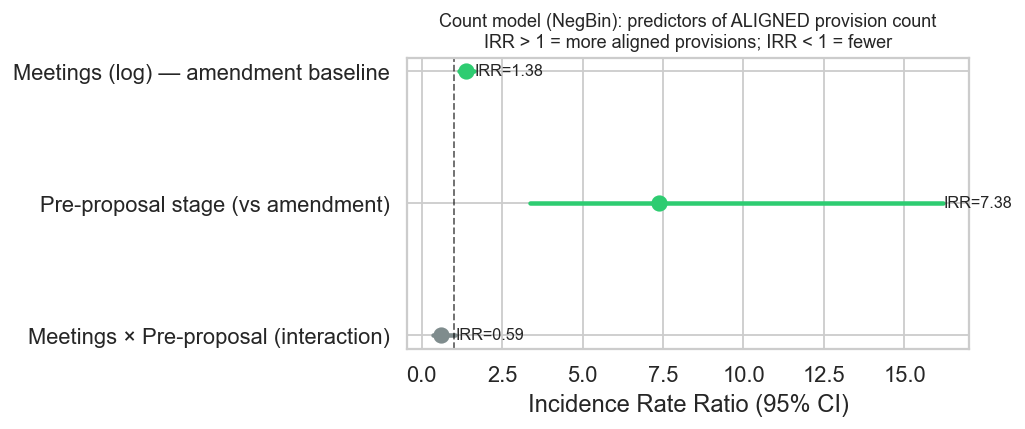


Interpretation guide:
IRR = Incidence Rate Ratio.
IRR of 2.0 on is_preproposal means: at pre-proposal, an org aligns with
2x as many provisions (per unit of corpus) as at amendment, holding meetings constant.


In [12]:
# ── Coefficient plot for Model 3 ───────────────────────────────────────────
m3 = models['Model 3 (+ interaction)']
core = ['log_meetings', 'is_preproposal', 'interaction']
labels_map = {
    'log_meetings':   'Meetings (log) — amendment baseline',
    'is_preproposal': 'Pre-proposal stage (vs amendment)',
    'interaction':    'Meetings × Pre-proposal (interaction)',
}

coefs = m3.params[core]
cis   = m3.conf_int().loc[core]

fig, ax = plt.subplots(figsize=(8, 3.5))
y_pos = range(len(core))[::-1]

for i, (param, y) in enumerate(zip(core, y_pos)):
    irr  = np.exp(coefs[param])
    lo   = np.exp(cis.loc[param, 0])
    hi   = np.exp(cis.loc[param, 1])
    color = '#2ecc71' if lo > 1 else ('#e74c3c' if hi < 1 else '#7f8c8d')
    ax.plot([lo, hi], [y, y], color=color, lw=2.5, solid_capstyle='round')
    ax.plot(irr, y, 'o', color=color, ms=8, zorder=5)
    ax.text(hi + 0.01, y, f'IRR={irr:.2f}', va='center', fontsize=9)

ax.axvline(1, color='black', ls='--', lw=1, alpha=0.6)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([labels_map[p] for p in core])
ax.set_xlabel('Incidence Rate Ratio (95% CI)')
ax.set_title('Count model (NegBin): predictors of ALIGNED provision count\n'
             'IRR > 1 = more aligned provisions; IRR < 1 = fewer', fontsize=10)
plt.tight_layout()
plt.savefig('analysis/fig_count_model_coef.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation guide:')
print('IRR = Incidence Rate Ratio.')
print('IRR of 2.0 on is_preproposal means: at pre-proposal, an org aligns with')
print('2x as many provisions (per unit of corpus) as at amendment, holding meetings constant.')

In [13]:
# ── OLS robustness check (log outcome) ─────────────────────────────────────
# Simpler model, easier to explain in thesis. Should tell the same story.
# Outcome: log(1 + count_aligned), no offset needed (it's about relative change)

reg['log_count_aligned'] = np.log1p(reg['count_aligned'])

ols_formula = f'log_count_aligned ~ log_meetings + is_preproposal + interaction + {proc_fe}'
ols = smf.ols(ols_formula, data=reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': reg['organisation']}
)

print('=== OLS robustness (log outcome, org-clustered SEs) ===')
core_p = ['log_meetings', 'is_preproposal', 'interaction']
print(pd.DataFrame({
    'coef':  ols.params[core_p].round(3),
    'se':    ols.bse[core_p].round(3),
    'p':     ols.pvalues[core_p].round(3),
}).to_string())
print(f'R²: {ols.rsquared:.3f}')
print()
print('Interpretation: coefficients are approximate % changes in aligned provision count.')
print('e.g., is_preproposal coef of 0.5 ≈ 50% more aligned provisions at pre-proposal.')

=== OLS robustness (log outcome, org-clustered SEs) ===
                 coef     se      p
log_meetings    0.375  0.076  0.000
is_preproposal -0.159  0.290  0.584
interaction    -0.555  0.217  0.010
R²: 0.249

Interpretation: coefficients are approximate % changes in aligned provision count.
e.g., is_preproposal coef of 0.5 ≈ 50% more aligned provisions at pre-proposal.


## 6. Summary table for thesis

Compact table showing key stats per procedure × stage — suitable for Table 4.4 replacement.

In [14]:
summary = (
    orgs.groupby(['proc_label', 'stage'])
    .agg(
        n_orgs           = ('organisation', 'nunique'),
        corpus_provs     = ('corpus_provisions', 'first'),
        median_aligned   = ('count_aligned', 'median'),
        mean_aligned     = ('count_aligned', 'mean'),
        orgs_any_aligned = ('count_aligned', lambda x: (x > 0).sum()),
        median_meetings  = ('meetings_total', 'median'),
    )
    .round(1)
    .reset_index()
)
summary['pct_orgs_aligned'] = (summary['orgs_any_aligned'] / summary['n_orgs'] * 100).round(1)

print('Key stats per procedure × stage:')
print(summary.to_string(index=False))

Key stats per procedure × stage:
  proc_label       stage  n_orgs  corpus_provs  median_aligned  mean_aligned  orgs_any_aligned  median_meetings  pct_orgs_aligned
      AI Act   amendment      11           347            13.0          14.5                 9              6.0              81.8
      AI Act preproposal      15            58             2.0           2.9                12              2.0              80.0
         CMA   amendment      20           377            18.0          19.2                18              2.5              90.0
         CMA preproposal       4            13             1.5           1.8                 4              2.0             100.0
       CSDDD   amendment      43           237             3.0           4.6                35              2.0              81.4
       CSDDD preproposal       5            13             3.0           3.4                 4              1.0              80.0
         DMA   amendment      28           588           

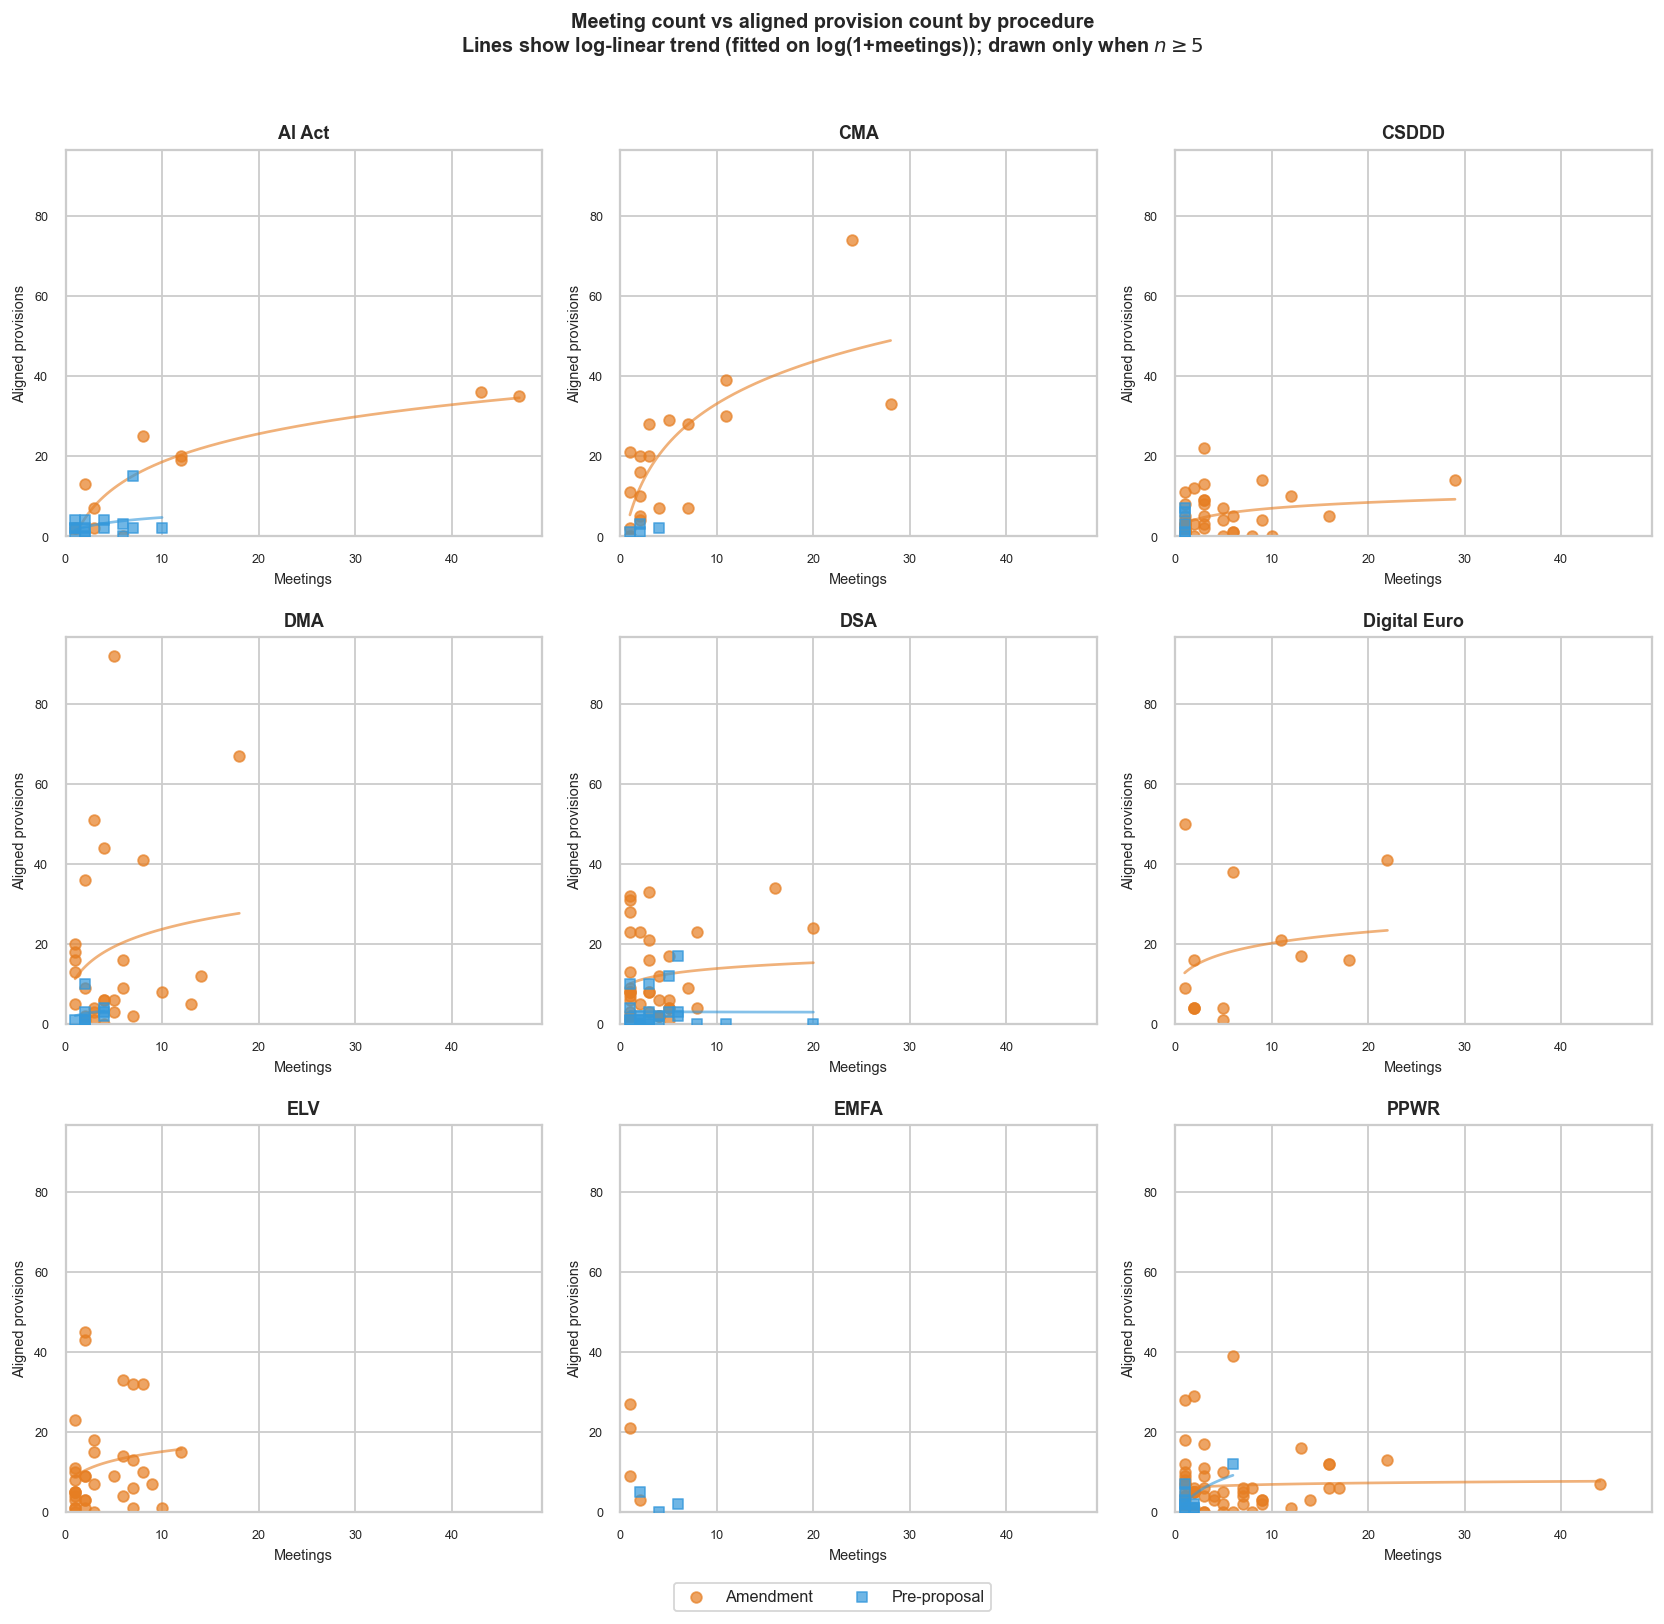

Saved fig_scatter_grid.png / .pdf


In [15]:
# 3x3 scatter grid: meetings vs aligned provision count, per procedure
# Shared axes so all panels are directly comparable
procs = sorted(orgs['proc_label'].unique())

x_max = orgs['meetings_total'].max() * 1.05
y_max = orgs['count_aligned'].max() * 1.05

fig, axes = plt.subplots(3, 3, figsize=(13, 12), sharex=False, sharey=False)
axes = axes.flatten()

for ax, proc in zip(axes, procs):
    sub = orgs[orgs['proc_label'] == proc]
    for stage, marker, zorder in [('amendment', 'o', 2), ('preproposal', 's', 3)]:
        s = sub[sub['stage'] == stage]
        ax.scatter(
            s['meetings_total'], s['count_aligned'],
            color=STAGE_COLORS[stage], alpha=0.7, s=35,
            marker=marker, zorder=zorder,
            label=stage.replace('preproposal', 'Pre-proposal').replace('amendment', 'Amendment')
        )
        x = np.log1p(s['meetings_total'])
        if len(s) >= 5 and x.std() > 0:
            y = s['count_aligned'].values.astype(float)
            xv = x.values
            coef = np.polyfit(xv, y, 1)
            x_range = np.linspace(xv.min(), xv.max(), 50)
            ax.plot(np.expm1(x_range), np.polyval(coef, x_range),
                    color=STAGE_COLORS[stage], lw=1.5, alpha=0.6)

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.set_title(proc, fontsize=10, fontweight='bold')
    ax.set_xlabel('Meetings', fontsize=8)
    ax.set_ylabel('Aligned provisions', fontsize=8)
    ax.tick_params(labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(seen.values(), seen.keys(),
           loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Meeting count vs aligned provision count by procedure\n'
             'Lines show log-linear trend (fitted on log(1+meetings)); drawn only when $n \geq 5$',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('analysis/fig_scatter_grid.png', dpi=150, bbox_inches='tight')
plt.savefig('analysis/fig_scatter_grid.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_scatter_grid.png / .pdf')


## 5b. Visual inspection before regression

**Why show this before the count model?**

The regression in Section 5 estimates an *average* relationship between meeting count
and aligned provisions across all procedures and stages simultaneously. Before trusting
that average, it is worth asking: does the relationship actually look consistent across
procedures, or is the regression picking up one or two outliers?

This 3×3 grid answers that question visually. Each panel shows one procedure.
Within each panel, orange dots are amendment-stage observations and blue squares are
pre-proposal. The trend lines (log-linear, drawn when n ≥ 5) show whether more meetings
tend to go with more aligned provisions *within* that procedure and stage.

**How it connects to the RQ:**

RQ2 asks whether access — proxied by meeting count — predicts textual alignment between
lobbying positions and legislative outcomes. The scatter grid is the raw, unaggregated
answer: you can see whether the pattern holds across very different legislative files
(a digital market regulation vs a packaging waste directive vs an AI act), or whether
it is specific to one context. It also makes the corpus-size asymmetry visible:
amendment dots sit higher on the y-axis in absolute terms, but the pre-proposal dots
tend to be clustered with relatively high alignment given how few meetings they represent
— the pattern the regression later quantifies as the stage effect.

**Note on sparsity:**  
Several panels have no pre-proposal trend line. This is because after the access filter,
only organisations with ≥ 1 disclosed meeting are included, and at the pre-proposal stage
that leaves very few observations per procedure. The sparsity is itself a finding —
it reflects how rarely an organisation both secures a pre-proposal meeting *and* leaves
a retrievable public position text.

In [16]:
# Binary outcome: did this org align with at least one provision?
reg['has_aligned'] = (reg['count_aligned'] > 0).astype(int)

print(f'Orgs with ≥1 aligned provision:  {reg["has_aligned"].sum()} / {len(reg)} '
      f'({reg["has_aligned"].mean()*100:.1f}%)')
print(f'By stage:')
print(reg.groupby('stage')['has_aligned'].agg(['sum','mean']).rename(
    columns={'sum':'n_has_aligned','mean':'share'}).round(3))

proc_fe = ' + '.join(proc_dummies) if proc_dummies else '0'

logit_formulas = {
    'Model 1 (meetings only)':          'has_aligned ~ log_meetings',
    'Model 2 (+ stage + proc FE)':      f'has_aligned ~ log_meetings + is_preproposal + {proc_fe}',
    'Model 3 (+ interaction)':          f'has_aligned ~ log_meetings + is_preproposal + interaction + {proc_fe}',
}

logit_models = {}
for name, formula in logit_formulas.items():
    m = smf.logit(formula, data=reg).fit(
        cov_type='cluster',
        cov_kwds={'groups': reg['organisation']},
        disp=False
    )
    logit_models[name] = m
    core = ['log_meetings', 'is_preproposal', 'interaction']
    show = [c for c in core if c in m.params.index]
    print(f'\n=== {name} ===')
    print(pd.DataFrame({
        'coef':           m.params[show].round(3),
        'OR = exp(coef)': np.exp(m.params[show]).round(3),
        'p':              m.pvalues[show].round(3),
    }).to_string())
    print(f'  Pseudo-R²: {1 - m.llf/m.llnull:.3f}  |  N={int(m.nobs)}')

Orgs with ≥1 aligned provision:  285 / 326 (87.4%)
By stage:
             n_has_aligned  share
stage                            
amendment              228  0.894
preproposal             57  0.803

=== Model 1 (meetings only) ===
               coef  OR = exp(coef)      p
log_meetings  0.255            1.29  0.272
  Pseudo-R²: 0.004  |  N=326

=== Model 2 (+ stage + proc FE) ===
                 coef  OR = exp(coef)      p
log_meetings    0.152           1.164  0.540
is_preproposal -0.649           0.523  0.111
  Pseudo-R²: 0.060  |  N=326

=== Model 3 (+ interaction) ===
                 coef  OR = exp(coef)      p
log_meetings    0.509           1.663  0.075
is_preproposal  1.293           3.643  0.150
interaction    -1.556           0.211  0.005
  Pseudo-R²: 0.085  |  N=326


## 7. Logistic regression at org × procedure × stage level

Same predictors as the count model but with a **binary outcome**:  
`has_aligned` = 1 if the org aligned with at least one provision, 0 otherwise.

This is the closest equivalent to the old dyad-level logistic regression, but with the  
correct unit of analysis (one row per org per procedure per stage, not one row per dyad).  
The old model repeated the same meetings value across all dyads for the same org,  
inflating N and diluting the signal. Here each org appears once per stage.